In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

(np.float64(-0.5), np.float64(249.5), np.float64(249.5), np.float64(-0.5))

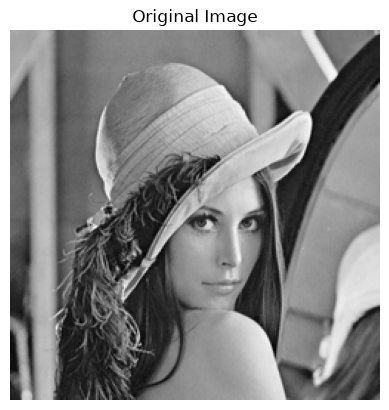

In [11]:
img_path = "../../images/lenna.png"
img = cv.imread(img_path, 0).astype(np.float64)

height, width = img.shape

MAX_INTENSITY = 255
MIN_INTENSITY = 0

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

1. Noises (Gaussian, Uniform, Impulse, Speckle, Poisson, Rayleigh, Periodic)

Each noise model perturbs pixel intensities differently:
- Gaussian: adds values drawn from a normal distribution N(0, sigma^2).
- Uniform: adds values drawn evenly from a range [a, b].
- Impulse (salt-and-pepper): randomly forces some pixels to 0 (pepper) or 255 (salt).
- Speckle: multiplicative noise, f + f * n, common in radar/ultrasound images.
- Poisson: signal-dependent "shot noise", where brighter pixels get noisier.
- Rayleigh: values drawn from a Rayleigh distribution, skewed towards small positive values.
- Periodic: a repeating sinusoidal pattern added across the image, from interference sources.

In [ ]:
# Parameters
gaussian_mean, gaussian_std = 0, 20  # higher std -> noisier, grainier image
uniform_min, uniform_max = -40, 40  # wider [min, max] range -> stronger, more visible noise
impulse_probability = 0.05  # higher probability -> more salt/pepper pixels flipped to 0 or 255
speckle_mean, speckle_std = 0, 0.2  # higher std -> stronger multiplicative noise, more grainy in bright regions
rayleigh_scale = 20  # larger scale -> stronger, more spread-out noise
period, periodic_amplitude = 10, 20  # shorter period -> tighter stripes; larger amplitude -> more visible banding

# Gaussian noise
gaussian_noise = np.random.normal(gaussian_mean, gaussian_std, img.shape)
gaussian_img = np.clip(img + gaussian_noise, MIN_INTENSITY, MAX_INTENSITY)

# Uniform noise
uniform_noise = np.random.uniform(uniform_min, uniform_max, img.shape)
uniform_img = np.clip(img + uniform_noise, MIN_INTENSITY, MAX_INTENSITY)

# Impulse noise
random_values = np.random.rand(height, width)
impulse_img = img.copy()
impulse_img[random_values < impulse_probability / 2] = MIN_INTENSITY
impulse_img[random_values > 1 - impulse_probability / 2] = MAX_INTENSITY

# Speckle noise
speckle_noise = np.random.normal(speckle_mean, speckle_std, img.shape)
speckle_img = np.clip(img + img * speckle_noise, MIN_INTENSITY, MAX_INTENSITY)

# Poisson noise
poisson_img = np.clip(np.random.poisson(img), MIN_INTENSITY, MAX_INTENSITY)

# Rayleigh noise
rayleigh_noise = np.random.rayleigh(rayleigh_scale, img.shape)
rayleigh_img = np.clip(img + rayleigh_noise, MIN_INTENSITY, MAX_INTENSITY)

# Periodic noise
x = np.arange(width)
periodic_noise = periodic_amplitude * np.sin(2 * np.pi * x / period)
periodic_img = np.clip(img + periodic_noise, MIN_INTENSITY, MAX_INTENSITY)

# Display
images = [
    ("Original", img), ("Gaussian", gaussian_img),
    ("Uniform", uniform_img), ("Impulse", impulse_img),
    ("Speckle", speckle_img), ("Poisson", poisson_img),
    ("Rayleigh", rayleigh_img), ("Periodic", periodic_img)
]

plt.figure(figsize=(12, 8))

for i, (title, image) in enumerate(images, 1):
    plt.subplot(2, 4, i)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

2. Filters for Noise Minimization
a. Mean filter
b. Averaging and weighted averaging

Linear smoothing filters replace each pixel with a weighted average of its neighbourhood:
- Mean/box filter: every neighbour gets equal weight $1/n^2$.
- Weighted average: a kernel such as $\frac{1}{16}\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix}$
  gives the centre pixel more importance, smoothing noise while keeping a bit more detail than a
  plain mean filter.

`cv.filter2D` convolves the image with either kernel directly.

In [ ]:
noisy = gaussian_img

mean_kernel = np.ones((3, 3), np.float32) / 9  # larger kernel -> stronger smoothing, more blur

weighted_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], np.float32) / 16

mean3 = cv.filter2D(noisy, -1, mean_kernel)
weighted3 = cv.filter2D(noisy, -1, weighted_kernel)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1), plt.imshow(noisy, cmap='gray'), plt.title("Noisy"), plt.axis("off")
plt.subplot(1, 3, 2), plt.imshow(mean3, cmap='gray'), plt.title("Mean Filter"), plt.axis("off")
plt.subplot(1, 3, 3), plt.imshow(weighted3, cmap='gray'), plt.title("Weighted Average"), plt.axis("off")

plt.show()

3. Non-linear spatial domain filter
a. Alpha trimmed mean filter
b. Minimum filter
c. Maximum filter
d. Median filter

Order-statistic filters sort the pixel values in a neighbourhood and pick a statistic instead of
averaging:
- Median: the middle value, very effective against impulse noise since it ignores outliers.
- Minimum: darkens the image, good for removing salt (bright) noise, but erodes bright detail.
- Maximum: brightens the image, good for removing pepper (dark) noise, but erodes dark detail.
- Alpha-trimmed mean: sort the neighbourhood, discard the d/2 smallest and d/2 largest values,
  then average what remains - a compromise between the mean and the median filter.

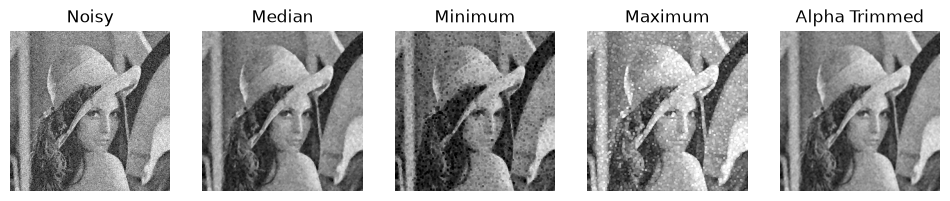

In [30]:
noisy = gaussian_img

kernel_size = 3  # larger window -> stronger smoothing/erosion-dilation effect from all the order-stat filters below
trim = 2  # more values trimmed -> alpha-trimmed mean behaves more like the median (robust); trim=0 is a plain mean
pad = kernel_size // 2

# Edge padding
padded = np.pad(noisy, pad, mode="edge")

# All neighbourhoods
windows = np.lib.stride_tricks.sliding_window_view(
    padded, (kernel_size, kernel_size)
)

# Median
median = np.median(windows, axis=(-2, -1))

# Minimum
minimum = np.min(windows, axis=(-2, -1))

# Maximum
maximum = np.max(windows, axis=(-2, -1))

# Alpha-trimmed mean
windows = windows.reshape(windows.shape[0], windows.shape[1], -1)
sorted_windows = np.sort(windows, axis=-1)
trimmed = sorted_windows[..., trim//2 : -trim//2]
alpha_trimmed = np.mean(trimmed, axis=-1)

# Display
plt.figure(figsize=(12, 4))

plt.subplot(1, 5, 1), plt.imshow(noisy, cmap="gray"), plt.title("Noisy"), plt.axis("off")
plt.subplot(1, 5, 2), plt.imshow(median, cmap="gray"), plt.title("Median"), plt.axis("off")
plt.subplot(1, 5, 3), plt.imshow(minimum, cmap="gray"), plt.title("Minimum"), plt.axis("off")
plt.subplot(1, 5, 4), plt.imshow(maximum, cmap="gray"), plt.title("Maximum"), plt.axis("off")
plt.subplot(1, 5, 5), plt.imshow(alpha_trimmed, cmap="gray"), plt.title("Alpha Trimmed"), plt.axis("off")

plt.show()

4. Anisotropic diffusion filter

Perona-Malik anisotropic diffusion smooths flat regions but not across edges. Each direction's
contribution is weighted by a conduction coefficient that shrinks wherever the gradient is large
(i.e. at an edge): $c = e^{-(\nabla I / \kappa)^2}$. The image is then updated iteratively,
$I \mathrel{+}= \lambda \sum_{\text{directions}} c \cdot \nabla I$, so diffusion happens freely in
smooth areas and is blocked at edges.

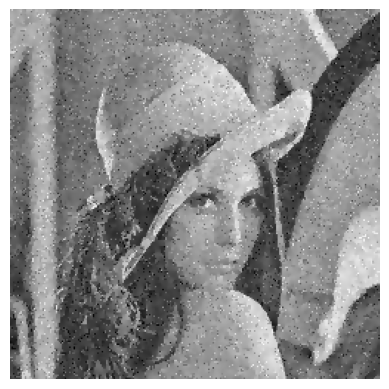

In [31]:
img = gaussian_img.astype(float)

iterations = 10  # more iterations -> more smoothing overall
K = 20  # larger K lets diffusion cross stronger gradients, blurring edges more; smaller K preserves edges better
lam = 0.2  # larger step size speeds up smoothing per iteration but can overshoot/become unstable if too large

for _ in range(iterations):
    n = np.roll(img, -1, 0) - img
    s = np.roll(img,  1, 0) - img
    e = np.roll(img, -1, 1) - img
    w = np.roll(img,  1, 1) - img

    img += lam * (
        n * np.exp(-(n/K) ** 2) +
        s * np.exp(-(s/K) ** 2) +
        e * np.exp(-(e/K) ** 2) +
        w * np.exp(-(w/K) ** 2)
    )

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

5. Fourier transform-based image denoising

Structured noise (e.g. the periodic noise above) concentrates its energy at specific frequencies,
which are often separable from the image's own frequency content. Transforming to the frequency
domain and multiplying by a low-pass mask $H = e^{-D^2/2D_0^2}$ suppresses that noise; the inverse
FFT then returns the cleaned spatial-domain image.

In [ ]:
height, width = img.shape

u, v = np.meshgrid(
    np.arange(width) - width // 2,
    np.arange(height) - height // 2
)

distance = np.sqrt(u**2 + v**2)

cutoff_frequency = 40  # larger cutoff keeps more high frequencies -> sharper but noisier result
gaussian_mask = np.exp(
    -(distance**2) / (2 * cutoff_frequency**2)
)

frequency_image = np.fft.fftshift(
    np.fft.fft2(periodic_img)
)

filtered_frequency = frequency_image * gaussian_mask

denoised_image = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(filtered_frequency)
    )
)

denoised_image = np.clip(
    denoised_image, 0, 255
).astype(np.uint8)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(periodic_img, cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denoised_image, cmap="gray")
plt.title("FFT Denoised")
plt.axis("off")

plt.show()

6. Image Restoration
a. Point spread function
   i. Out-of-focus blur
   ii. Atmospheric turbulence blur
   iii. Motion blur

A degradation is modeled as convolution with a point spread function (PSF), $g = f * h$:
- Out-of-focus blur: a uniform disk PSF of a given radius.
- Motion blur: a line PSF along the direction of motion (spreads each point along that line).
- Atmospheric turbulence blur: a smooth, low-pass-like frequency response,
  $H = e^{-k D^{5/3}}$, that widens as turbulence increases.

The two spatial PSFs (disk, line) are applied with `cv.filter2D`, same as the filters above.

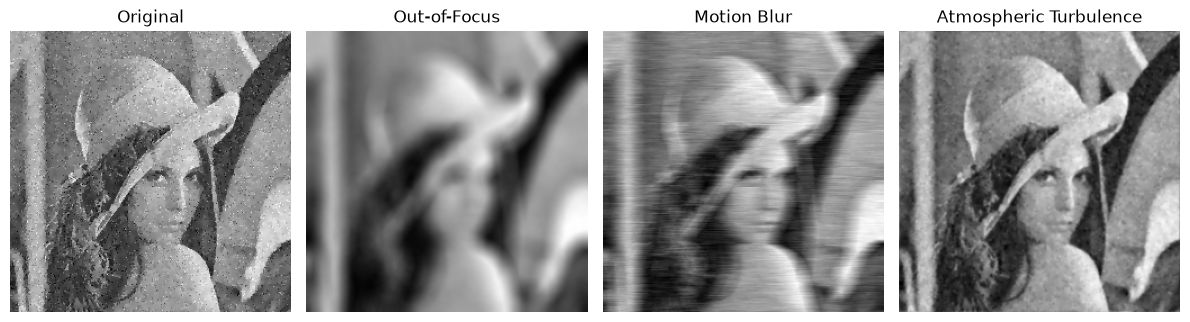

In [32]:
# Parameters
out_of_focus_radius = 10  # larger radius -> stronger, more spread-out blur
motion_length = 15  # longer motion length -> longer smear, stronger directional blur
turbulence_strength = 0.001  # larger value -> faster falloff of high frequencies, more severe turbulence blur

# 1. Out-of-focus blur — disk PSF
out_of_focus_psf = np.zeros((height, width), np.float32)
cv.circle(
    out_of_focus_psf,
    (width // 2, height // 2),
    out_of_focus_radius,
    1,
    -1
)
out_of_focus_psf /= out_of_focus_psf.sum()

out_of_focus_blur = cv.filter2D(
    img, -1, out_of_focus_psf
)

# 2. Motion blur — line PSF
motion_psf = np.zeros(
    (motion_length, motion_length),
    np.float32
)
motion_psf[motion_length // 2, :] = 1
motion_psf /= motion_psf.sum()

motion_blur = cv.filter2D(
    img, -1, motion_psf
)

# 3. Atmospheric turbulence — frequency response
u, v = np.meshgrid(
    np.arange(width) - width // 2,
    np.arange(height) - height // 2
)

distance = np.sqrt(u**2 + v**2)

turbulence_H = np.exp(
    -turbulence_strength * distance**(5 / 3)
)

frequency_image = np.fft.fftshift(
    np.fft.fft2(img)
)

turbulence_frequency = frequency_image * turbulence_H

turbulence_blur = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(turbulence_frequency)
    )
)

# Display
images = [
    ("Original", img),
    ("Out-of-Focus", out_of_focus_blur),
    ("Motion Blur", motion_blur),
    ("Atmospheric Turbulence", turbulence_blur)
]

plt.figure(figsize=(12, 4))

for i, (title, image) in enumerate(images, 1):
    plt.subplot(1, 4, i)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

b. Inverse filter
c. Pseudo-inverse filter
d. Weiner filter

Given the degradation model $G = F \cdot H$ (plus noise $N$ in practice):
- Inverse filter: recovers $\hat F = G / H$ directly - exact when there is no noise, but blows up
  wherever $H \approx 0$, amplifying any noise present.
- Pseudo-inverse filter: only inverts where $|H|$ exceeds a small threshold, setting the rest to
  zero, which avoids dividing by near-zero values.
- Wiener filter: balances restoration against noise using
  $\hat F = \dfrac{H^*}{|H|^2 + K} G$, where $K$ approximates the noise-to-signal ratio; small $K$
  behaves like the inverse filter, larger $K$ suppresses noise amplification at the cost of some
  remaining blur.

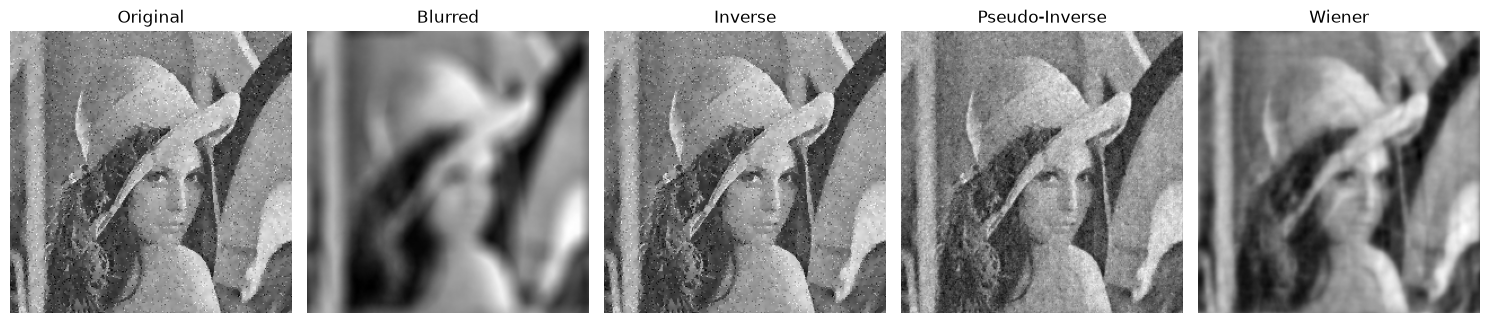

In [33]:
blur_radius = 10       # larger radius -> stronger degrading blur to restore from
threshold = 0.01       # pseudo-inverse cutoff: raising it ignores more near-zero H values, trading sharpness for stability
noise_ratio = 0.01     # Wiener K: larger K suppresses noise amplification more but leaves more residual blur


# Out-of-focus PSF
psf = np.zeros((height, width))
cv.circle(psf, (width // 2, height // 2), blur_radius, 1, -1)
psf /= psf.sum()

# Frequency domain
F = np.fft.fftshift(np.fft.fft2(img))
H = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(psf)))
G = F * H

# Restoration
inverse = G / H
pseudo_inverse = np.where(np.abs(H) > threshold, G / H, 0)
wiener = (np.conj(H) / (np.abs(H)**2 + noise_ratio)) * G

# Back to spatial domain
images = [
    ("Original", img),
    ("Blurred", np.abs(np.fft.ifft2(np.fft.ifftshift(G)))),
    ("Inverse", np.abs(np.fft.ifft2(np.fft.ifftshift(inverse)))),
    ("Pseudo-Inverse", np.abs(np.fft.ifft2(np.fft.ifftshift(pseudo_inverse)))),
    ("Wiener", np.abs(np.fft.ifft2(np.fft.ifftshift(wiener))))
]

plt.figure(figsize=(15, 4))

for i, (title, image) in enumerate(images, 1):
    plt.subplot(1, 5, i)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()